## 1. Установка random seed и импорт библиотек

In [2]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import random
import nltk
from nltk.corpus import stopwords
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

# Установка random seed для воспроизводимости результатов
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Random seed установлен на значение:", RANDOM_SEED)

D:\setup\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Random seed установлен на значение: 42


## 2. Загрузка данных 

Источник: https://www.kaggle.com/datasets/yutkin/corpus-of-russian-news-articles-from-lenta?resource=download

In [3]:
# Загрузка данных
df = pd.read_csv('lenta-ru-news.csv')

# Вывод информации о датасете
print("Размер датасета:", len(df))
print("Количество уникальных топиков:", df['topic'].nunique())
print("Уникальные топики:", df['topic'].unique())

print("\nПримеры записей:")
print(df.head())

Размер датасета: 800975
Количество уникальных топиков: 23
Уникальные топики: ['Библиотека' 'Россия' 'Мир' 'Экономика' 'Интернет и СМИ' 'Спорт'
 'Культура' 'Из жизни' 'Силовые структуры' 'Наука и техника' 'Бывший СССР'
 nan 'Дом' 'Сочи' 'ЧМ-2014' 'Путешествия' 'Ценности' 'Легпром' 'Бизнес'
 'МедНовости' 'Оружие' '69-я параллель' 'Культпросвет ' 'Крым']

Примеры записей:
                                           url  \
0   https://lenta.ru/news/1914/09/16/hungarnn/   
1  https://lenta.ru/news/1914/09/16/lermontov/   
2  https://lenta.ru/news/1914/09/17/nesteroff/   
3   https://lenta.ru/news/1914/09/17/bulldogn/   
4       https://lenta.ru/news/1914/09/18/zver/   

                                               title  \
0  1914. Русские войска вступили в пределы Венгрии     
1  1914. Празднование столетия М.Ю. Лермонтова от...   
2                           1914. Das ist Nesteroff!   
3                    1914. Бульдог-гонец под Льежем    
4           1914. Под Люблином пойман швабский 

## 3. Анализ датасета

Размер датасета: 800975
Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800975 entries, 0 to 800974
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     800975 non-null  object
 1   title   800975 non-null  object
 2   text    800970 non-null  object
 3   topic   738973 non-null  object
 4   tags    773756 non-null  object
 5   date    800975 non-null  object
dtypes: object(6)
memory usage: 36.7+ MB
None

Количество уникальных топиков: 23
5 наиболее частых топиков:
topic
Россия       160445
Мир          136621
Экономика     79528
Спорт         64413
Культура      53797
Name: count, dtype: int64


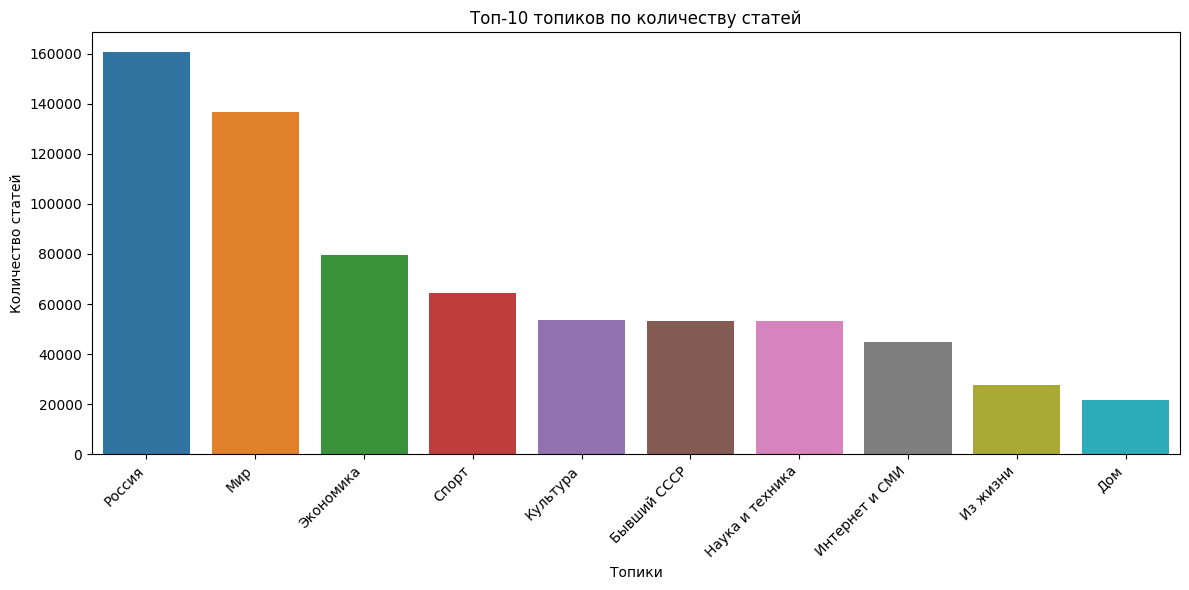

In [4]:
# Выводим основную информацию о датасете
print("Размер датасета:", len(df))
print("Информация о столбцах:")
print(df.info())

# Проверим количество уникальных топиков
print("\nКоличество уникальных топиков:", df['topic'].nunique())
print("5 наиболее частых топиков:")
print(df['topic'].value_counts().head())

# Отображаем распределение топиков
plt.figure(figsize=(12, 6))
top_topics = df['topic'].value_counts().head(10)
sns.barplot(x=top_topics.index, y=top_topics.values)
plt.title('Топ-10 топиков по количеству статей')
plt.ylabel('Количество статей')
plt.xlabel('Топики')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Базовая предобработка текста

In [5]:
# Загружаем необходимые ресурсы NLTK
nltk.download('stopwords')

# Получаем стоп-слова для русского языка
russian_stopwords = stopwords.words('russian')

# Для ускорения обработки ограничимся выборкой
sample_size = 100000  # Используем выборку в 100000 записей
if len(df) > sample_size:
    df_sample = df.sample(sample_size, random_state=RANDOM_SEED)
    print(f"Выборка уменьшена до {sample_size} записей для демонстрации")
else:
    df_sample = df.copy()

print(f"Работаем с выборкой размером {len(df_sample)} записей")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Выборка уменьшена до 100000 записей для демонстрации
Работаем с выборкой размером 100000 записей


## 5. Функция предобработки текста

In [6]:
# Функция для предобработки текста
def preprocess_text(text):
    if not isinstance(text, str) or pd.isna(text):
        return ""  # Возвращаем пустую строку для NaN и не-строк
    
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Удаление специальных символов и цифр
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Токенизация и фильтрация стоп-слов
    tokens = [token for token in text.split() if token not in russian_stopwords and len(token) > 2]
    
    # Объединение обратно в текст
    return ' '.join(tokens)

# Функция для токенизации текста (для обучения word2vec)
def tokenize_text(text):
    if not isinstance(text, str) or pd.isna(text):
        return []
    
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Удаление специальных символов и цифр
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Токенизация и фильтрация стоп-слов
    tokens = [token for token in text.split() if token not in russian_stopwords and len(token) > 2]
    
    return tokens

## 6. Предобработка

In [7]:
# Отслеживание прогресса
tqdm.pandas()

# Применение предобработки
print("Начинаем предобработку текстов...")
df_sample['processed_title'] = df_sample['title'].progress_apply(preprocess_text)
df_sample['processed_text'] = df_sample['text'].progress_apply(preprocess_text)
df_sample['processed_combined'] = df_sample['processed_title'] + ' ' + df_sample['processed_text']

# Токенизация для word2vec
print("Токенизация текстов для обучения word2vec...")
df_sample['tokenized_text'] = df_sample['processed_combined'].progress_apply(tokenize_text)

# Проверка на NaN значения
print("\nПроверка на пропущенные значения после предобработки:")
print(df_sample[['processed_title', 'processed_text', 'processed_combined']].isna().sum())

# Заполняем NaN значения пустыми строками, если остались
df_sample['processed_title'] = df_sample['processed_title'].fillna('')
df_sample['processed_text'] = df_sample['processed_text'].fillna('')
df_sample['processed_combined'] = df_sample['processed_combined'].fillna('')

# Проверка на NaN в целевой переменной
print("\nПроверка на пропущенные значения в топиках:")
print(df_sample['topic'].isna().sum())

# Удаляем строки с NaN в целевой переменной
if df_sample['topic'].isna().sum() > 0:
    print("Удаляем строки с пропущенными значениями в целевой переменной")
    df_sample = df_sample.dropna(subset=['topic'])
    print(f"Осталось {len(df_sample)} строк после удаления")

print("Предобработка завершена.")
print("\nПримеры обработанных текстов:")
for i in range(min(3, len(df_sample))):
    print(f"Оригинальный заголовок: {df_sample['title'].iloc[i]}")
    print(f"Обработанный заголовок: {df_sample['processed_title'].iloc[i]}")
    print(f"Токенизированный текст (первые 10 токенов): {df_sample['tokenized_text'].iloc[i][:10]}")
    print(f"Топик: {df_sample['topic'].iloc[i]}")
    print("---")

Начинаем предобработку текстов...


  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

Токенизация текстов для обучения word2vec...


  0%|          | 0/100000 [00:00<?, ?it/s]


Проверка на пропущенные значения после предобработки:
processed_title       0
processed_text        0
processed_combined    0
dtype: int64

Проверка на пропущенные значения в топиках:
7615
Удаляем строки с пропущенными значениями в целевой переменной
Осталось 92385 строк после удаления
Предобработка завершена.

Примеры обработанных текстов:
Оригинальный заголовок: Жена Оззи Осборна выиграла суд против британского таблоида
Обработанный заголовок: жена оззи осборна выиграла суд против британского таблоида
Токенизированный текст (первые 10 токенов): ['жена', 'оззи', 'осборна', 'выиграла', 'суд', 'против', 'британского', 'таблоида', 'жена', 'лидера']
Топик: Культура
---
Оригинальный заголовок: В Осло вручили международную премию Абеля по математике
Обработанный заголовок: осло вручили международную премию абеля математике
Токенизированный текст (первые 10 токенов): ['осло', 'вручили', 'международную', 'премию', 'абеля', 'математике', 'международная', 'абелевская', 'премия', 'учрежденная']

## 7. Разделение данных на выборки

In [8]:
# Убедимся, что у нас нет пустых значений в топиках
df_sample = df_sample.dropna(subset=['topic'])

# Проверяем, сколько у нас образцов для каждого класса
class_counts = df_sample['topic'].value_counts()
print("Количество образцов для каждого класса:")
print(class_counts.head(10))  # Показываем топ-10 классов

# Находим классы с малым количеством образцов (меньше 3)
small_classes = class_counts[class_counts < 3].index.tolist()
if small_classes:
    print(f"\nНайдены классы с малым количеством образцов: {small_classes}")
    print("Удаляем эти классы для возможности стратификации")
    df_sample = df_sample[~df_sample['topic'].isin(small_classes)]
    print(f"Осталось {len(df_sample)} строк после удаления редких классов")

# Разделение данных на обучающую, валидационную и тестовую выборки
# Сначала отделим тестовую часть (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    df_sample, 
    df_sample['topic'], 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=df_sample['topic']
)

# Затем разделим оставшуюся часть на обучающую (60% от всего) и валидационную (20% от всего)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2 (от всего)
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f"Размер обучающей выборки: {len(X_train)} (60%)")
print(f"Размер валидационной выборки: {len(X_val)} (20%)")
print(f"Размер тестовой выборки: {len(X_test)} (20%)")

# Проверим стратификацию
print("\nРаспределение классов в выборках:")
print("Обучающая выборка:", y_train.value_counts(normalize=True).head())
print("Валидационная выборка:", y_val.value_counts(normalize=True).head())
print("Тестовая выборка:", y_test.value_counts(normalize=True).head())

Количество образцов для каждого класса:
topic
Россия             19824
Мир                16942
Экономика           9977
Спорт               8215
Бывший СССР         6772
Наука и техника     6711
Культура            6662
Интернет и СМИ      5591
Из жизни            3503
Дом                 2661
Name: count, dtype: int64

Найдены классы с малым количеством образцов: ['МедНовости']
Удаляем эти классы для возможности стратификации
Осталось 92384 строк после удаления редких классов
Размер обучающей выборки: 55430 (60%)
Размер валидационной выборки: 18477 (20%)
Размер тестовой выборки: 18477 (20%)

Распределение классов в выборках:
Обучающая выборка: topic
Россия         0.214577
Мир            0.183384
Экономика      0.107992
Спорт          0.088923
Бывший СССР    0.073300
Name: proportion, dtype: float64
Валидационная выборка: topic
Россия         0.214591
Мир            0.183363
Экономика      0.107972
Спорт          0.088921
Бывший СССР    0.073334
Name: proportion, dtype: float64
Тесто

## 8. Обучение word2vec эмбеддингов с помощью gensim

In [9]:
# Используем только обучающую выборку для обучения word2vec
sentences = X_train['tokenized_text'].tolist()

# Задаем параметры для обучения модели word2vec
vector_size = 300  # Размерность эмбеддингов: 300 - стандартный выбор для баланса между качеством и производительностью
window = 5  # Размер окна контекста: 5 слов до и после целевого слова (типичное значение)
min_count = 5  # Минимальная частота слова: игнорируем редкие слова для уменьшения шума
workers = 4  # Количество потоков: ускоряет обучение на многоядерных процессорах
sg = 1  # Использование модели Skip-gram (sg=1) вместо CBOW (sg=0): лучше работает для редких слов и фраз
epochs = 10  # Количество проходов по корпусу: больше эпох = лучше качество, но дольше обучение

print("Обучение модели Word2Vec с параметрами:")
print(f"vector_size={vector_size}, window={window}, min_count={min_count}, workers={workers}, sg={sg}, epochs={epochs}")
print("Обучение может занять некоторое время...")

# Создание и обучение модели word2vec
w2v_model = Word2Vec(
    sentences, 
    vector_size=vector_size, 
    window=window, 
    min_count=min_count, 
    workers=workers, 
    sg=sg,
    epochs=epochs,
    seed=RANDOM_SEED
)

# Сохранение модели в файл
w2v_model.save("lenta_w2v_model.model")
print("Модель word2vec обучена и сохранена в файл")

Обучение модели Word2Vec с параметрами:
vector_size=300, window=5, min_count=5, workers=4, sg=1, epochs=10
Обучение может занять некоторое время...
Модель word2vec обучена и сохранена в файл


## 9. Визуальная оценка качества эмбеддингов

In [10]:
# Функция для визуализации и оценки качества эмбеддингов
def visualize_embeddings_evaluation(model):
    # Демонстрация most_similar
    print("Демонстрация most_similar:")
    similar_words = model.wv.most_similar('россия', topn=10)
    print("Слова, наиболее похожие на 'россия':")
    for word, similarity in similar_words:
        print(f"  {word}: {similarity:.4f}")
    
    # Демонстрация most_similar для других ключевых слов
    for query_word in ['москва', 'политика', 'экономика', 'спорт']:
        if query_word in model.wv:
            print(f"\nСлова, наиболее похожие на '{query_word}':")
            similar = model.wv.most_similar(query_word, topn=5)
            for word, similarity in similar:
                print(f"  {word}: {similarity:.4f}")
    
    # Демонстрация doesn't_match
    print("\nДемонстрация doesn't_match:")
    try:
        test_cases = [
            ["москва", "санкт-петербург", "новосибирск", "яблоко"],
            ["путин", "медведев", "лавров", "стол"],
            ["экономика", "финансы", "политика", "кошка"],
            ["футбол", "хоккей", "теннис", "математика"]
        ]
        
        for words in test_cases:
            # Проверяем, что все слова есть в модели
            if all(word in model.wv for word in words):
                odd_word = model.wv.doesnt_match(words)
                print(f"Среди {', '.join(words)} лишнее слово: {odd_word}")
            else:
                missing = [word for word in words if word not in model.wv]
                print(f"Не могу проверить {words}, отсутствуют слова: {missing}")
    except Exception as e:
        print("Проблема с методом doesn't_match:", e)
    
    # Визуализация эмбеддингов с помощью t-SNE
    try:
        from sklearn.manifold import TSNE
        
        # Выберем топ-100 наиболее частых слов из модели
        word_vectors = []
        words = []
        
        for word in list(model.wv.index_to_key)[:100]:
            word_vectors.append(model.wv[word])
            words.append(word)
        
        if len(word_vectors) > 0:
            # Применение t-SNE для снижения размерности
            tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=min(30, len(word_vectors)-1))
            embedded_vectors = tsne.fit_transform(word_vectors)
            
            # Визуализация
            plt.figure(figsize=(10, 8))
            plt.scatter(embedded_vectors[:, 0], embedded_vectors[:, 1], edgecolors='k', c='lightblue')
            
            # Добавление аннотаций (слов) к точкам
            for i, word in enumerate(words):
                plt.annotate(word, xy=(embedded_vectors[i, 0], embedded_vectors[i, 1]))
            
            plt.title('t-SNE визуализация Word2Vec эмбеддингов')
            plt.xlabel('t-SNE компонента 1')
            plt.ylabel('t-SNE компонента 2')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"Ошибка при визуализации t-SNE: {e}")

# Вызов функции визуализации для оценки качества эмбеддингов
print("\nВизуальная оценка качества эмбеддингов:")
visualize_embeddings_evaluation(w2v_model)


Визуальная оценка качества эмбеддингов:
Демонстрация most_similar:
Слова, наиболее похожие на 'россия':
  единая: 0.5649
  украина: 0.5634
  франция: 0.5491
  молдавия: 0.5374
  финляндия: 0.5230
  белоруссия: 0.5186
  турция: 0.5168
  индия: 0.5165
  киргизия: 0.5068
  аргентина: 0.5066

Слова, наиболее похожие на 'москва':
  варшава: 0.4928
  санктпетербург: 0.4881
  россия: 0.4777
  симметричными: 0.4716
  анкара: 0.4560

Слова, наиболее похожие на 'политика':
  нереальная: 0.4593
  редакционная: 0.4207
  поддержу: 0.4109
  чиновника: 0.4056
  гайдар: 0.4053

Слова, наиболее похожие на 'экономика':
  рецессия: 0.6180
  инфляция: 0.6035
  ввп: 0.5969
  макроэкономическая: 0.5960
  замедление: 0.5743

Слова, наиболее похожие на 'спорт':
  sportsru: 0.5789
  чемпионатcom: 0.5748
  спортэкспресс: 0.5722
  sportboxru: 0.5680
  чемпионатру: 0.5547

Демонстрация doesn't_match:
Не могу проверить ['москва', 'санкт-петербург', 'новосибирск', 'яблоко'], отсутствуют слова: ['санкт-петербург']


## 10. Загрузка предобученных эмбеддингов

In [11]:
# Функция для загрузки Navec
def load_navec():
    try:
        from navec import Navec
        navec_path = 'navec_hudlit_v1_12B_500K_300d_100q.tar'
        
        # Проверка существования файла
        if not os.path.exists(navec_path):
            print(f"Файл {navec_path} не найден. Загружаем...")
            import urllib.request
            urllib.request.urlretrieve('https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar', navec_path)
            print("Загрузка завершена.")
        
        navec = Navec.load(navec_path)
        print("Navec загружен успешно.")
        
        # Создание словаря для быстрого доступа к векторам
        navec_embeddings = {}
        for word in navec.vocab.words:
            navec_embeddings[word] = navec[word]
        
        # Размерность эмбеддингов navec
        navec_vector_size = navec.pq.dim
        print(f"Размерность эмбеддингов navec: {navec_vector_size}")
        
        return navec_embeddings, navec_vector_size
    except Exception as e:
        print(f"Ошибка при загрузке Navec: {e}")
        return None, 300

# Функция для загрузки RusVectores
def load_rusvectores():
    try:
        from gensim.models import KeyedVectors
        rusvec_path = 'rusvectores_model.bin'
        
        # Проверка существования файла
        if not os.path.exists(rusvec_path):
            print(f"Файл {rusvec_path} не найден. Загружаем...")
            import urllib.request
            urllib.request.urlretrieve('https://rusvectores.org/static/models/rusvectores4/RNC/ruscorpora_upos_skipgram_300_5_2018.vec.gz', 'ruscorpora_upos_skipgram_300_5_2018.vec.gz')
            
            # Распаковка gz архива
            import gzip
            import shutil
            with gzip.open('ruscorpora_upos_skipgram_300_5_2018.vec.gz', 'rb') as f_in:
                with open('ruscorpora_upos_skipgram_300_5_2018.vec', 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            
            # Загрузка модели и преобразование в бинарный формат для ускорения
            rus_model = KeyedVectors.load_word2vec_format('ruscorpora_upos_skipgram_300_5_2018.vec')
            rus_model.save_word2vec_format(rusvec_path, binary=True)
            print("Загрузка и преобразование завершены.")
        
        rusvec = KeyedVectors.load_word2vec_format(rusvec_path, binary=True)
        print("RusVectores загружен успешно.")
        
        # Создание словаря для быстрого доступа к векторам
        rusvec_embeddings = {}
        for word in rusvec.index_to_key:
            # В rusvectores слова часто имеют метки POS (например, "кошка_NOUN")
            # Можно извлечь только слово:
            if '_' in word:
                clean_word = word.split('_')[0].lower()
                rusvec_embeddings[clean_word] = rusvec[word]
            else:
                rusvec_embeddings[word.lower()] = rusvec[word]
        
        # Размерность эмбеддингов rusvectores
        rusvec_vector_size = rusvec.vector_size
        print(f"Размерность эмбеддингов rusvectores: {rusvec_vector_size}")
        
        return rusvec_embeddings, rusvec_vector_size
    except Exception as e:
        print(f"Ошибка при загрузке RusVectores: {e}")
        return None, 300

# Загрузка предобученных эмбеддингов
print("\nЗагрузка предобученных эмбеддингов...")
navec_embeddings, navec_vector_size = load_navec()
rusvec_embeddings, rusvec_vector_size = load_rusvectores()


Загрузка предобученных эмбеддингов...
Ошибка при загрузке Navec: No module named 'navec'
Файл rusvectores_model.bin не найден. Загружаем...
Загрузка и преобразование завершены.
RusVectores загружен успешно.
Размерность эмбеддингов rusvectores: 300


## 11. Создание признаков на основе эмбеддингов

In [12]:
# Функция для создания признаков на основе word2vec эмбеддингов
def create_document_vector(document, model, vector_size=300):
    words = document.split()
    word_vectors = []
    
    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])
    
    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    
    # Усреднение векторов всех слов в документе
    document_vector = np.mean(word_vectors, axis=0)
    return document_vector

# Функция для создания признаков на основе navec или rusvectores эмбеддингов
def create_document_vector_pretrained(document, embeddings, vector_size=300):
    words = document.split()
    word_vectors = []
    
    for word in words:
        if word in embeddings:
            word_vectors.append(embeddings[word])
    
    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    
    # Усреднение векторов всех слов в документе
    document_vector = np.mean(word_vectors, axis=0)
    return document_vector

# Функция для создания признаков с взвешиванием через tf-idf
def create_tfidf_weighted_document_vector(document, model, tfidf_vectorizer, tfidf_matrix, idx, vector_size=300):
    words = document.split()
    word_vectors = []
    word_weights = []
    
    # Получаем индексы и значения tf-idf для текущего документа
    doc_tfidf = tfidf_matrix[idx]
    
    # Создаем словарь {слово: tfidf_вес} для этого документа
    word_to_tfidf = {}
    
    # Если документ не пустой
    if doc_tfidf.nnz > 0:
        # Получаем индексы слов с ненулевыми значениями tf-idf
        indices = doc_tfidf.indices
        # Получаем значения tf-idf для этих слов
        values = doc_tfidf.data
        
        # Сопоставляем индексы с соответствующими словами и их значениями tf-idf
        for idx, value in zip(indices, values):
            word = tfidf_vectorizer.get_feature_names_out()[idx]
            word_to_tfidf[word] = value
    
    # Вычисляем взвешенное среднее векторов слов
    for word in words:
        if word in model.wv and word in word_to_tfidf:
            word_vectors.append(model.wv[word] * word_to_tfidf[word])
            word_weights.append(word_to_tfidf[word])
    
    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    
    # Взвешенное среднее
    if sum(word_weights) > 0:
        document_vector = np.sum(word_vectors, axis=0) / sum(word_weights)
    else:
        document_vector = np.mean(word_vectors, axis=0)
    
    return document_vector

# Создание признаков
print("\nСоздание признаков на основе эмбеддингов...")

# Для собственной модели word2vec
print("Создание признаков на основе собственных word2vec эмбеддингов...")
X_train_w2v = np.array([create_document_vector(doc, w2v_model, vector_size) for doc in tqdm(X_train['processed_combined'])])
X_val_w2v = np.array([create_document_vector(doc, w2v_model, vector_size) for doc in tqdm(X_val['processed_combined'])])
X_test_w2v = np.array([create_document_vector(doc, w2v_model, vector_size) for doc in tqdm(X_test['processed_combined'])])

# Для rusvectores (если доступно)
if rusvec_embeddings:
    print("Создание признаков на основе rusvectores эмбеддингов...")
    X_train_rusvec = np.array([create_document_vector_pretrained(doc, rusvec_embeddings, rusvec_vector_size) for doc in tqdm(X_train['processed_combined'])])
    X_val_rusvec = np.array([create_document_vector_pretrained(doc, rusvec_embeddings, rusvec_vector_size) for doc in tqdm(X_val['processed_combined'])])
    X_test_rusvec = np.array([create_document_vector_pretrained(doc, rusvec_embeddings, rusvec_vector_size) for doc in tqdm(X_test['processed_combined'])])
else:
    X_train_rusvec, X_val_rusvec, X_test_rusvec = None, None, None


Создание признаков на основе эмбеддингов...
Создание признаков на основе собственных word2vec эмбеддингов...


  0%|          | 0/55430 [00:00<?, ?it/s]

  0%|          | 0/18477 [00:00<?, ?it/s]

  0%|          | 0/18477 [00:00<?, ?it/s]

Создание признаков на основе rusvectores эмбеддингов...


  0%|          | 0/55430 [00:00<?, ?it/s]

  0%|          | 0/18477 [00:00<?, ?it/s]

  0%|          | 0/18477 [00:00<?, ?it/s]

## 12. Обучение моделей LogisticRegression с разными эмбеддингами

In [13]:
# Функция для обучения и оценки модели
def train_and_evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test, model_name):
    print(f"\nОбучение LogisticRegression с {model_name}...")
    
    # Обучение модели
    model = LogisticRegression(
        random_state=RANDOM_SEED,
        max_iter=1000,
        solver='saga',
        n_jobs=-1,
        C=1.0
    )
    model.fit(X_train, y_train)
    
    # Оценка на валидационной выборке
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    print(f"Точность на валидационной выборке ({model_name}): {val_accuracy:.4f}")
    
    # Оценка на тестовой выборке
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Точность на тестовой выборке ({model_name}): {test_accuracy:.4f}")
    
    # Отчет о классификации
    print(f"\nОтчет о классификации на валидационной выборке ({model_name}):")
    print(classification_report(y_val, y_val_pred, zero_division=0))
    
    return model, val_accuracy, test_accuracy

# Обучение моделей с разными эмбеддингами
results = {}

# С word2vec
w2v_model_lr, w2v_val_acc, w2v_test_acc = train_and_evaluate_model(
    X_train_w2v, X_val_w2v, X_test_w2v, 
    y_train, y_val, y_test, 
    "word2vec"
)
results["word2vec"] = {"val_acc": w2v_val_acc, "test_acc": w2v_test_acc}

# С RusVectores (если доступно)
if X_train_rusvec is not None:
    rusvec_model, rusvec_val_acc, rusvec_test_acc = train_and_evaluate_model(
        X_train_rusvec, X_val_rusvec, X_test_rusvec, 
        y_train, y_val, y_test, 
        "rusvectores"
    )
    results["rusvectores"] = {"val_acc": rusvec_val_acc, "test_acc": rusvec_test_acc}

# Определение лучшего набора эмбеддингов по валидационной точности
best_embedding = max(results, key=lambda x: results[x]["val_acc"])
print(f"\nЛучший набор эмбеддингов: {best_embedding} с валидационной точностью: {results[best_embedding]['val_acc']:.4f}")


Обучение LogisticRegression с word2vec...
Точность на валидационной выборке (word2vec): 0.7875
Точность на тестовой выборке (word2vec): 0.7924

Отчет о классификации на валидационной выборке (word2vec):
                   precision    recall  f1-score   support

   69-я параллель       1.00      0.10      0.18        30
       Библиотека       0.00      0.00      0.00         1
           Бизнес       0.49      0.09      0.15       196
      Бывший СССР       0.79      0.76      0.77      1355
              Дом       0.86      0.76      0.81       532
         Из жизни       0.66      0.59      0.62       701
   Интернет и СМИ       0.72      0.66      0.69      1118
             Крым       0.00      0.00      0.00        17
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.86      0.86      0.86      1333
          Легпром       0.00      0.00      0.00         3
              Мир       0.78      0.83      0.80      3388
  Наука и техника       0.83

## 13. Улучшение качества модели с использованием tf-idf взвешивания

In [18]:
# Создание tf-idf матрицы
print("\nУлучшение качества модели с использованием tf-idf взвешивания...")
print("Создание tf-idf матрицы...")
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf_sparse = tfidf_vectorizer.fit_transform(X_train['processed_combined'])
X_val_tfidf_sparse = tfidf_vectorizer.transform(X_val['processed_combined'])
X_test_tfidf_sparse = tfidf_vectorizer.transform(X_test['processed_combined'])

# Создание tf-idf взвешенных векторов для word2vec (лучший набор эмбеддингов)
print("Создание tf-idf взвешенных векторов...")
X_train_w2v_tfidf = np.array([
    create_tfidf_weighted_document_vector(doc, w2v_model, tfidf_vectorizer, X_train_tfidf_sparse, i, vector_size)
    for i, doc in enumerate(tqdm(X_train['processed_combined']))
])

X_val_w2v_tfidf = np.array([
    create_tfidf_weighted_document_vector(doc, w2v_model, tfidf_vectorizer, X_val_tfidf_sparse, i, vector_size)
    for i, doc in enumerate(tqdm(X_val['processed_combined']))
])

X_test_w2v_tfidf = np.array([
    create_tfidf_weighted_document_vector(doc, w2v_model, tfidf_vectorizer, X_test_tfidf_sparse, i, vector_size)
    for i, doc in enumerate(tqdm(X_test['processed_combined']))
])

# Обучение модели с tf-idf взвешиванием
w2v_tfidf_model, w2v_tfidf_val_acc, w2v_tfidf_test_acc = train_and_evaluate_model(
    X_train_w2v_tfidf, X_val_w2v_tfidf, X_test_w2v_tfidf, 
    y_train, y_val, y_test, 
    "word2vec+tfidf"
)
results["word2vec+tfidf"] = {"val_acc": w2v_tfidf_val_acc, "test_acc": w2v_tfidf_test_acc}


Улучшение качества модели с использованием tf-idf взвешивания...
Создание tf-idf матрицы...
Создание tf-idf взвешенных векторов...


  0%|          | 0/55430 [00:00<?, ?it/s]

  0%|          | 0/18477 [00:00<?, ?it/s]

  0%|          | 0/18477 [00:00<?, ?it/s]


Обучение LogisticRegression с word2vec+tfidf...
Точность на валидационной выборке (word2vec+tfidf): 0.6775
Точность на тестовой выборке (word2vec+tfidf): 0.6867

Отчет о классификации на валидационной выборке (word2vec+tfidf):
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00        30
       Библиотека       0.00      0.00      0.00         1
           Бизнес       0.37      0.05      0.09       196
      Бывший СССР       0.69      0.57      0.63      1355
              Дом       0.78      0.64      0.70       532
         Из жизни       0.50      0.39      0.43       701
   Интернет и СМИ       0.60      0.45      0.52      1118
             Крым       0.00      0.00      0.00        17
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.67      0.69      0.68      1333
          Легпром       0.00      0.00      0.00         3
              Мир       0.68      0.75      0.72      3388
  На

## Выводы

- лучше всего показала себя модель word2vec c качеством на тестовой выборке 0.7924